num_records: 3420
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
             q_len       hit@10  gold_n  pred_n
count  3420.000000  3420.000000  3420.0  3420.0
mean     43.273099     0.829532     1.0     5.0
std      38.488611     0.376098     0.0     0.0
min       4.000000     0.000000     1.0     5.0
25%      21.000000     1.000000     1.0     5.0
50%      31.000000     1.000000     1.0     5.0
75%      51.000000     1.000000     1.0     5.0
max     382.000000     1.000000     1.0     5.0
       len_bin    n  hit_rate
0       (0, 8]    6  0.833333
1      (8, 16]  393  0.725191
2     (16, 24]  789  0.808619
3     (24, 32]  610  0.845902
4     (32, 48]  692  0.862717
5     (48, 64]  363  0.887052
6     (64, 96]  322  0.866460
7    (96, 128]  116  0.818966
8   (128, 192]   84  0.809524
9   (192, 256]   28  0.642857
10  (256, 384]   17  0.823529


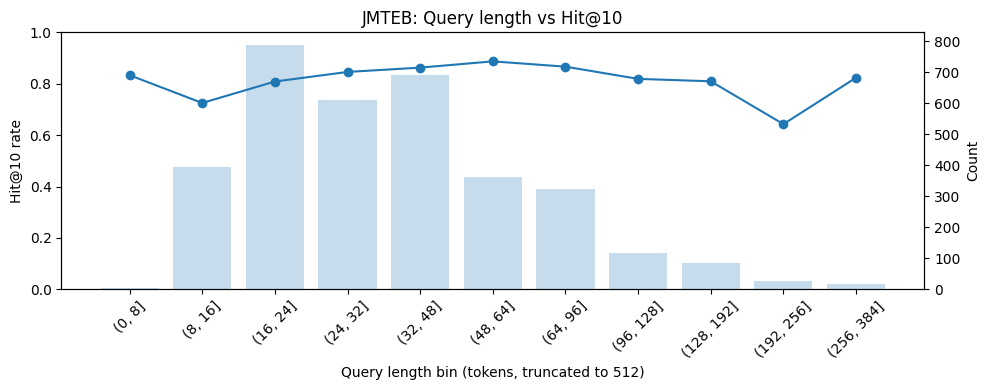

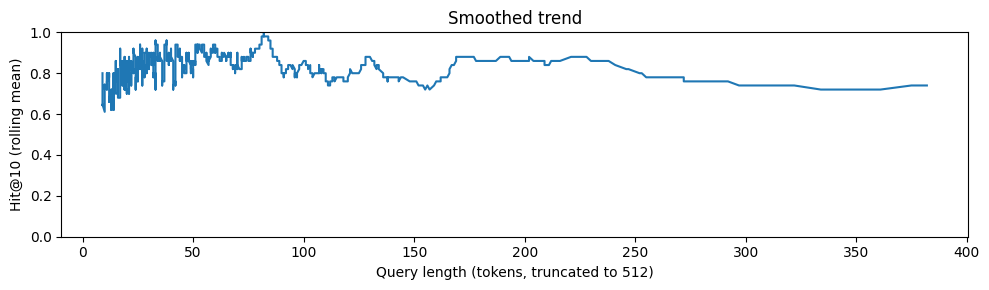

In [21]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_jagovfaqs_22k_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

num_records: 3420
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
             q_len       hit@10  gold_n  pred_n
count  3420.000000  3420.000000  3420.0  3420.0
mean     43.273099     0.285088     1.0     5.0
std      38.488611     0.451522     0.0     0.0
min       4.000000     0.000000     1.0     5.0
25%      21.000000     0.000000     1.0     5.0
50%      31.000000     0.000000     1.0     5.0
75%      51.000000     1.000000     1.0     5.0
max     382.000000     1.000000     1.0     5.0
       len_bin    n  hit_rate
0       (0, 8]    6  0.333333
1      (8, 16]  393  0.096692
2     (16, 24]  789  0.126743
3     (24, 32]  610  0.206557
4     (32, 48]  692  0.365607
5     (48, 64]  363  0.460055
6     (64, 96]  322  0.540373
7    (96, 128]  116  0.396552
8   (128, 192]   84  0.571429
9   (192, 256]   28  0.428571
10  (256, 384]   17  0.529412


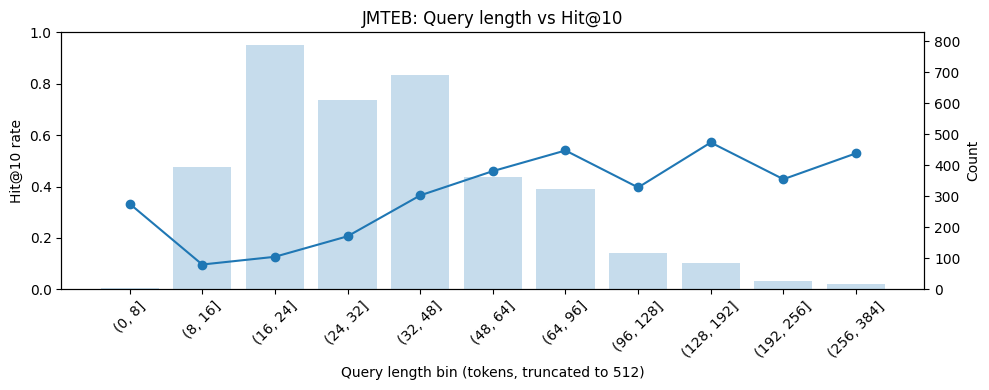

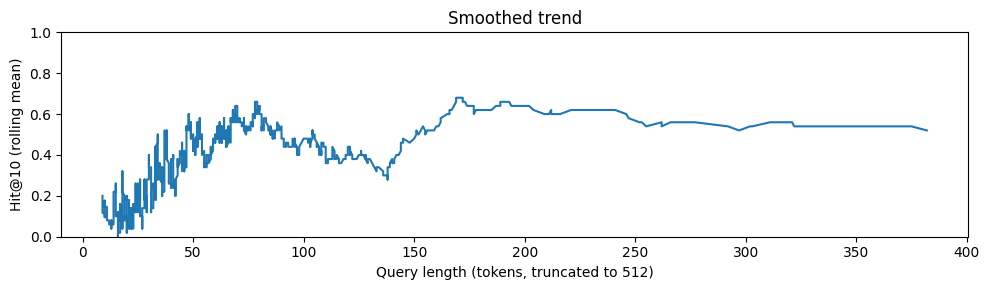

In [8]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_w8a16_PT_htp_v73/Retrieval/predictions_jagovfaqs_22k_Noned.jsonl"
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

num_records: 510
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
            q_len      hit@10  gold_n  pred_n
count  510.000000  510.000000   510.0   510.0
mean   313.852941    0.909804     1.0     5.0
std     98.272585    0.286744     0.0     0.0
min     16.000000    0.000000     1.0     5.0
25%    244.000000    1.000000     1.0     5.0
50%    303.000000    1.000000     1.0     5.0
75%    377.750000    1.000000     1.0     5.0
max    512.000000    1.000000     1.0     5.0
      len_bin    n  hit_rate
0     (8, 16]    1  0.000000
1    (64, 96]    1  0.000000
2   (96, 128]    5  0.600000
3  (128, 192]   46  0.804348
4  (192, 256]  100  0.870000
5  (256, 384]  240  0.937500
6  (384, 512]  117  0.957265


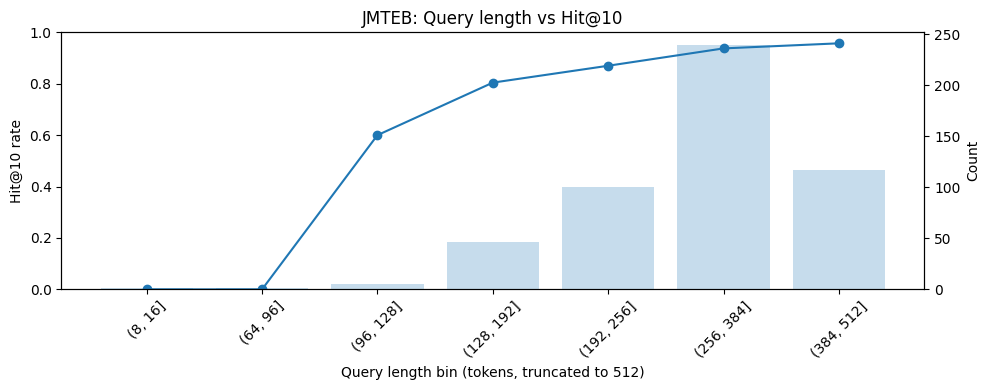

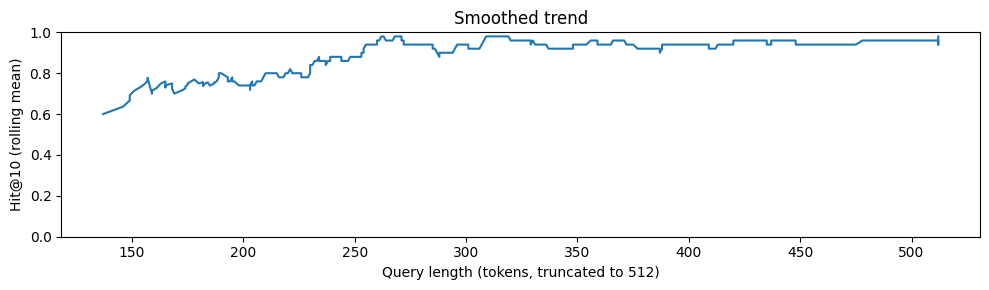

In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

num_records: 510
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
            q_len      hit@10  gold_n  pred_n
count  510.000000  510.000000   510.0   510.0
mean   313.852941    0.937255     1.0     5.0
std     98.272585    0.242742     0.0     0.0
min     16.000000    0.000000     1.0     5.0
25%    244.000000    1.000000     1.0     5.0
50%    303.000000    1.000000     1.0     5.0
75%    377.750000    1.000000     1.0     5.0
max    512.000000    1.000000     1.0     5.0
      len_bin    n  hit_rate
0     (8, 16]    1  0.000000
1    (64, 96]    1  1.000000
2   (96, 128]    5  1.000000
3  (128, 192]   46  0.934783
4  (192, 256]  100  0.890000
5  (256, 384]  240  0.945833
6  (384, 512]  117  0.965812


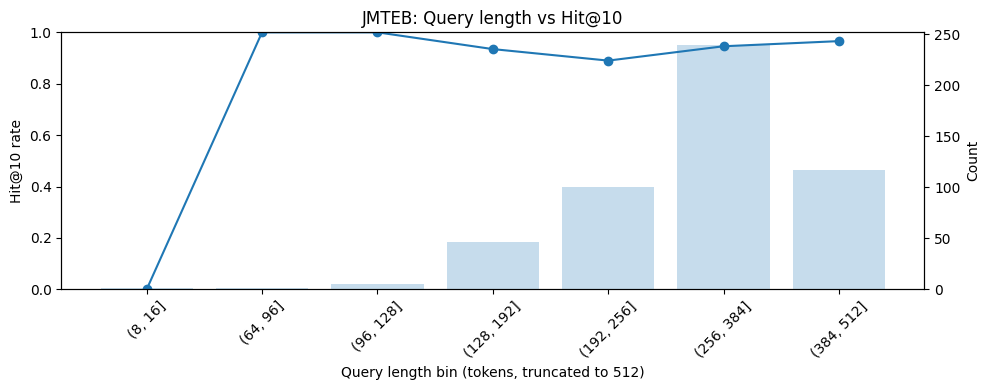

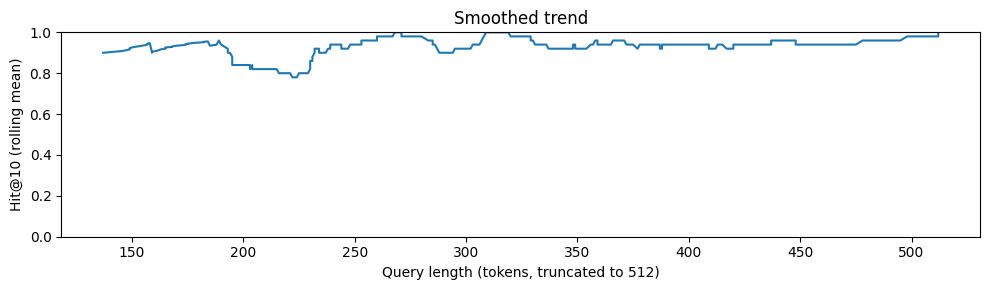

In [4]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

rows: 1000
columns: Index(['text'], dtype='str')
count    1000.000000
mean      411.277000
std       122.340449
min        16.000000
25%       293.000000
50%       512.000000
75%       512.000000
max       512.000000
Name: len, dtype: float64


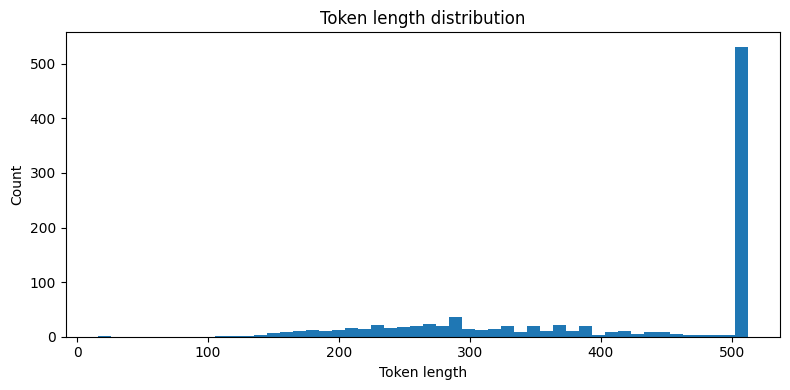

In [22]:
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ===== 設定 =====
ARROW_PATH = "/root/AIMET_ENV/tools/ruri/data/merged_1000.arrow"
TEXT_COL = "text"   # or "query"
MODEL_NAME = "cl-nagoya/ruri-small-v2"
MAXLEN = 512

# ===== Arrow読み込み =====
def load_arrow(path):
    with pa.memory_map(path, "r") as source:
        reader = ipc.RecordBatchStreamReader(source)
        table = reader.read_all()
    return table.to_pandas()

df = load_arrow(ARROW_PATH)
print("rows:", len(df))
print("columns:", df.columns)

# ===== tokenizer =====
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True
)

# ===== 長さ計算 =====
def calc_len(text):
    return len(tok(
        text,
        truncation=True,
        max_length=MAXLEN
    )["input_ids"])

df["len"] = df[TEXT_COL].astype(str).apply(calc_len)

print(df["len"].describe())

# ===== ヒストグラム =====
plt.figure(figsize=(8,4))
plt.hist(df["len"], bins=50)
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("Token length distribution")
plt.tight_layout()
plt.show()